# Enviroment Setup

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import xgboost as xgb
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# !!! ACTION REQUIRED !!! - update paths for your project structure

DRIVE_PATH = 'YOUR_PATH'

DATA_DIR = f'{DRIVE_PATH}/02_processed_data'
RES_DIR = f'{DRIVE_PATH}/05_prediction_results'
VIS_DIR = f'{DRIVE_PATH}/03_visualizations/Experiments/XGBOOST'

# Processed Data

In [4]:
DATASETS = {
    'Boralesgamuwa': {
        'file': 'boralasgamuwa_processed.csv',
        'label': 'Boralesgamuwa UC (Sri Lanka)',
        'code': 'bo',
        'number': '1'
    },
    'Dehiwala': {
        'file': 'dehiwala_processed.csv',
        'label': 'Dehiwala MC (Sri Lanka)',
        'code': 'de',
        'number': '2'
    },
    'Homagama': {
        'file': 'homagama_processed.csv',
        'label': 'Homagama PS (Sri Lanka)',
        'code': 'ho',
        'number': '3'
    },
    'Moratuwa': {
        'file': 'moratuwa_processed.csv',
        'label': 'Moratuwa MC (Sri Lanka)',
        'code': 'mo',
        'number': '4'
    },
    'Austin': {
        'file': 'austin_processed.csv',
        'label': 'Austin TX (USA)',
        'code': 'au',
        'number': '5'
    },
    'Ballarat': {
        'file': 'ballarat_processed.csv',
        'label': 'Ballarat (Australia)',
        'code': 'ba',
        'number': '6'
    }
}

In [5]:
FEATURES = [
    'year', 'month', 'day_of_week', 'day_of_year', 'week_of_year',
    'is_weekend', 'is_holiday', 'is_after_weekend', 'is_after_holiday',
    'tavg', 'prcp', 'wspd',
    'lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14', 'lag_30',
    'rolling_7_mean', 'rolling_7_std', 'rolling_30_mean',
    'month_sin', 'month_cos', 'dow_sin', 'dow_cos'
]

TARGET = 'total_tonnes'

# Model Definition - XGBoost

In [7]:
from sklearn.model_selection import GridSearchCV

print("=" *100)
print("XGBOOST HYPERPARAMETER TUNING")
print("=" * 100)

# load any dataset for tuning
tune_file = os.path.join(DATA_DIR, 'boralasgamuwa_processed.csv')
tune_df = pd.read_csv(tune_file)
tune_df['date'] = pd.to_datetime(tune_df['date'])
tune_df = tune_df.sort_values('date').reset_index(drop=True)

available_features = [f for f in FEATURES if f in tune_df.columns]

# not use test data
X_tune = tune_df.iloc[:-90][available_features]
y_tune = tune_df.iloc[:-90][TARGET]

param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1]
}

print(f"Tuning on {len(X_tune)} samples with {len(available_features)} features...")
print(f"Grid size: {np.prod([len(v) for v in param_grid.values()])} combinations (with CV=3)")

grid = GridSearchCV(
    xgb.XGBRegressor(objective='reg:squarederror', random_state=42),
    param_grid,
    cv=3,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=1
)
grid.fit(X_tune, y_tune)

print(f"\nBest parameters found:")
for param, value in grid.best_params_.items():
    print(f"  {param}: {value}")
print(f"Best CV MAE: {-grid.best_score_/1000:.2f} tonnes")

BEST_PARAMS = grid.best_params_

XGBOOST HYPERPARAMETER TUNING
Tuning on 2287 samples with 25 features...
Grid size: 48 combinations (with CV=3)
Fitting 3 folds for each of 48 candidates, totalling 144 fits

Best parameters found:
  learning_rate: 0.05
  max_depth: 4
  n_estimators: 200
Best CV MAE: 0.01 tonnes


In [8]:
def run_xgboost_prediction(df, dataset_name, dataset_code, dataset_number, features, test_days=90):
    """
    Train XGBoost on a single dataset and return metrics + predictions.
    Uses walk-forward prediction: for each test day, uses actual lag values
    from previous days (including already-predicted test days).
    """
    print(f"\n{'='*100}")
    print(f"XGBOOST PREDICTION — {dataset_name}")
    print(f"{'='*100}")

    df = df.sort_values('date').reset_index(drop=True)

    # feature filtering
    available_features = [f for f in features if f in df.columns]
    missing_features = [f for f in features if f not in df.columns]
    if missing_features:
        print(f"Note: Missing features (skipped): {missing_features}")

    # test / train split
    split_idx = len(df) - test_days
    train = df.iloc[:split_idx].copy()
    test = df.iloc[split_idx:].copy()

    print(f"Train: {len(train)} days ({train['date'].min().date()} → {train['date'].max().date()})")
    print(f"Test:  {len(test)} days ({test['date'].min().date()} → {test['date'].max().date()})")
    print(f"Features used: {len(available_features)}")

    # model fit
    X_train = train[available_features]
    y_train = train[TARGET]

    model = xgb.XGBRegressor(
        **BEST_PARAMS,
        random_state=2,
        objective='reg:squarederror'
    )
    model.fit(X_train, y_train, verbose=False)
    print("Model trained.")

    # walk-forward prediction on test set - no negatives
    predictions = []
    test_copy = test.copy()

    for i in range(len(test_copy)):
        row = test_copy.iloc[i:i+1][available_features]
        pred = model.predict(row)[0]
        pred = max(pred, 0)
        predictions.append(pred)

        # update lag features for next predictions
        idx = test_copy.index[i]
        if i + 1 < len(test_copy):
            next_idx = test_copy.index[i + 1]
            if 'lag_1' in available_features:
                test_copy.loc[next_idx, 'lag_1'] = pred
            if 'lag_2' in available_features and i + 2 < len(test_copy):
                test_copy.loc[test_copy.index[min(i+2, len(test_copy)-1)], 'lag_2'] = pred

    y_true = test[TARGET].values
    y_pred = np.array(predictions)

    # metrics
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    nonzero_mask = y_true > 0
    if nonzero_mask.sum() > 0:
        mape = np.mean(np.abs((y_true[nonzero_mask] - y_pred[nonzero_mask]) / y_true[nonzero_mask])) * 100
    else:
        mape = float('nan')

    print(f"\n--- RESULTS ---")
    print(f"MAE:  {mae:.2f} tonnes")
    print(f"RMSE: {rmse:.2f} tonnes")
    print(f"MAPE: {mape:.2f}%")


    # --- Plot 2X1: Actual vs Predicted (test period) - XGBoost ---
    fig, ax = plt.subplots(figsize=(16, 6))

    context = train.iloc[-30:]
    ax.plot(context['date'], context[TARGET], color='steelblue',
            linewidth=1, label='Training Data (last 30 days)')

    ax.plot(test['date'], y_true, color='steelblue',
            linewidth=1.5, label='Actual (Test)')

    ax.plot(test['date'], y_pred, color='red',
            linewidth=1.5, linestyle='--', label='XGBoost Forecast')

    ax.axvline(x=test['date'].iloc[0], color='gray', linestyle=':', alpha=0.7, label='Train/Test Split')

    ax.set_title(f'XGBoost Forecast vs Actual — {dataset_name}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Tonnes/day')
    ax.set_xlabel('Date')
    ax.legend(fontsize=10)

    ax.text(0.02, 0.95,
            f'MAE: {mae:.2f}t\nRMSE: {rmse:.2f}t\nMAPE: {mape:.1f}%',
            transform=ax.transAxes, fontsize=11, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

    plt.tight_layout()

    plt.savefig(os.path.join(VIS_DIR, f'2{dataset_number}1_xgb_forecast_{dataset_code}.png'), dpi=150, bbox_inches='tight')
    plt.show()


    # --- Plot 2X2: Zoom on firts 30 days of test - XGBoost ---
    fig, ax = plt.subplots(figsize=(14, 5))

    zoom_days = min(30, test_days)
    ax.plot(test['date'].iloc[:zoom_days], y_true[:zoom_days],
            color='steelblue', linewidth=2, marker='o', markersize=3, label='Actual')

    ax.plot(test['date'].iloc[:zoom_days], y_pred[:zoom_days],
            color='red', linewidth=2, marker='s', markersize=3, linestyle='--', label='XGBoost')

    ax.set_title(f'XGBoost Forecast (First {zoom_days} Days) — {dataset_name}', fontsize=14, fontweight='bold')
    ax.set_ylabel('Tonnes/day')
    ax.legend()
    plt.xticks(rotation=45)
    plt.tight_layout()

    plt.savefig(os.path.join(VIS_DIR, f'2{dataset_number}2_xgb_forecast_zoom_{dataset_code}.png'), dpi=150, bbox_inches='tight')
    plt.show()


    # --- Plot 2X3: Feature importance - XGBoost ---
    fig, ax = plt.subplots(figsize=(10, 8))

    importance = pd.Series(model.feature_importances_, index=available_features)
    importance = importance.sort_values(ascending=True)
    importance.tail(15).plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')

    ax.set_title(f'Top 15 Feature Importance — {dataset_name}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Importance')
    plt.tight_layout()

    plt.savefig(os.path.join(VIS_DIR, f'2{dataset_number}3_xgb_feature_importance_{dataset_code}.png'), dpi=150, bbox_inches='tight')
    plt.show()


    return {
        'dataset': dataset_name,
        'model': 'XGBoost',
        'mae': round(mae, 2),
        'rmse': round(rmse, 2),
        'mape': round(mape, 2),
        'test_days': test_days
    }

# Model Prediction - XGBoost


XGBOOST PREDICTION — Boralesgamuwa UC (Sri Lanka)
Train: 2287 days (2012-01-31 → 2018-09-29)
Test:  90 days (2018-09-30 → 2018-12-31)
Features used: 25
Model trained.

--- RESULTS ---
MAE:  5.90 tonnes
RMSE: 8.14 tonnes
MAPE: 39.23%


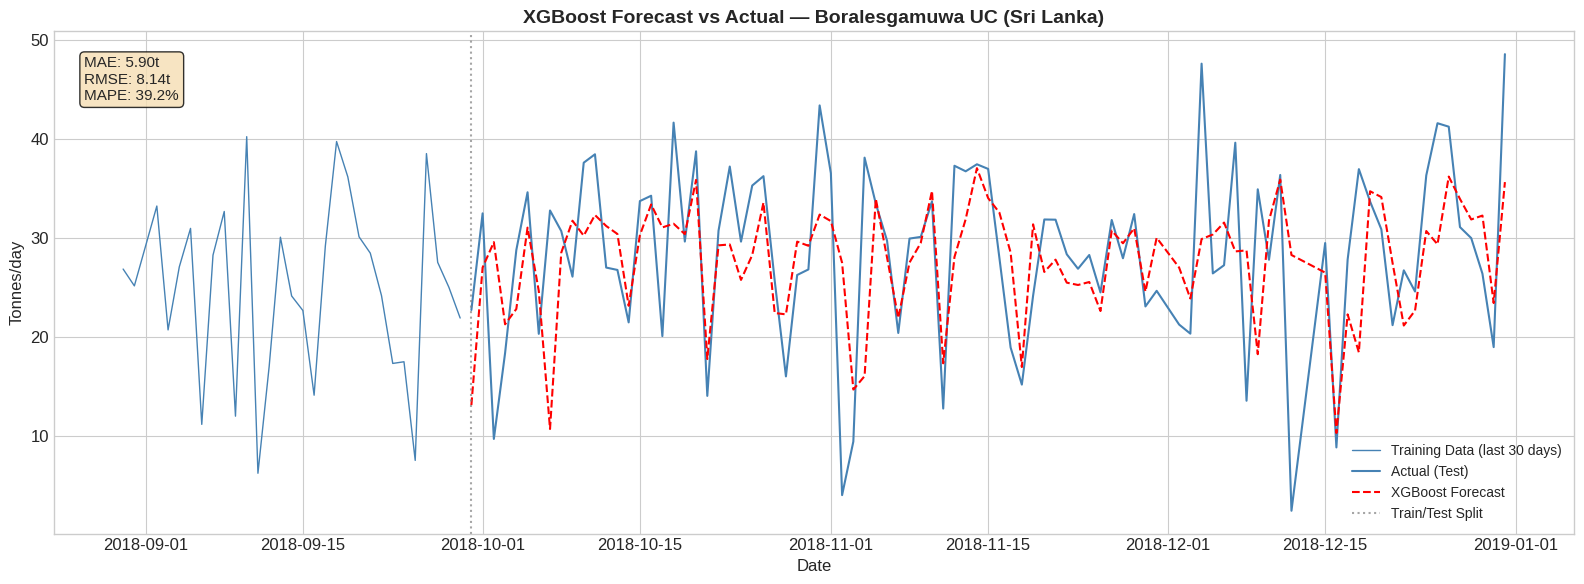

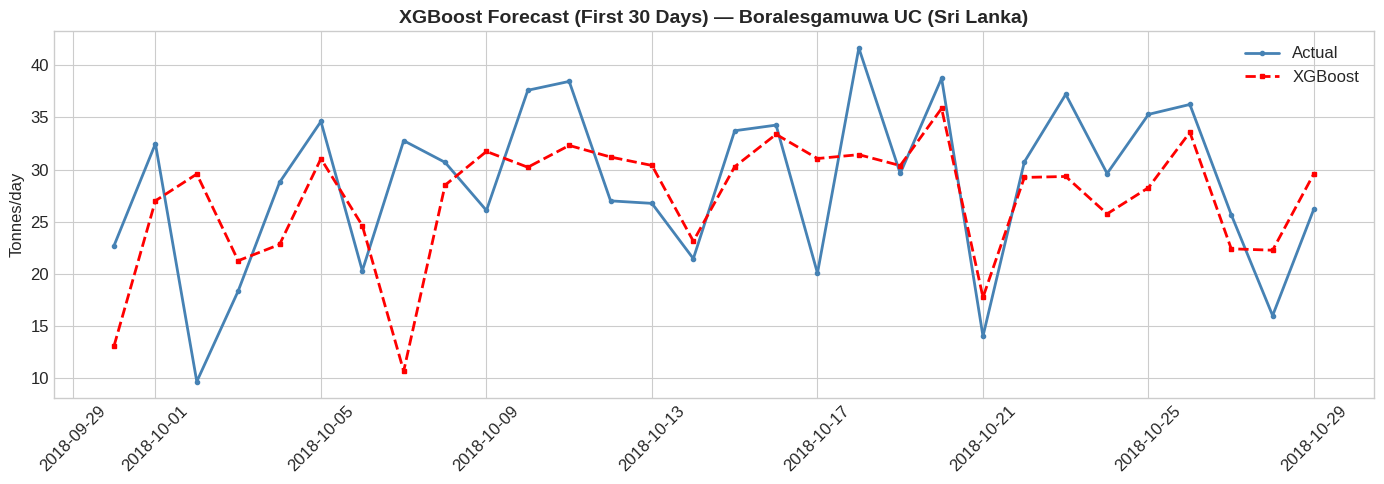

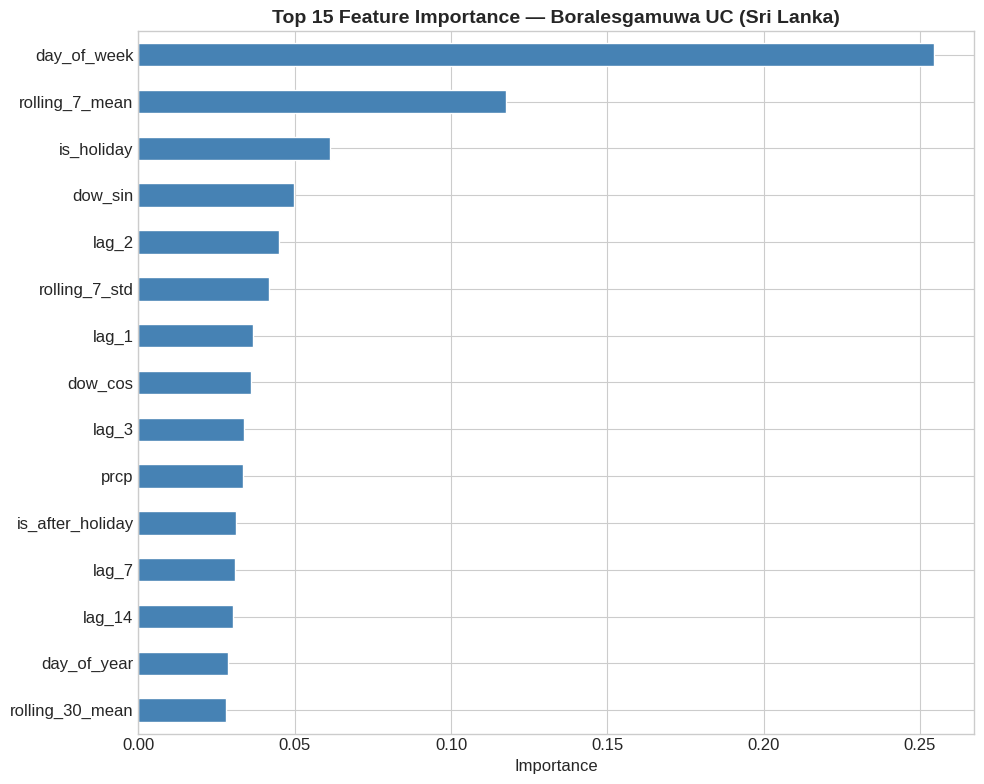


XGBOOST PREDICTION — Dehiwala MC (Sri Lanka)
Train: 2003 days (2012-01-31 → 2018-09-25)
Test:  90 days (2018-09-26 → 2018-12-31)
Features used: 25
Model trained.

--- RESULTS ---
MAE:  23.57 tonnes
RMSE: 33.58 tonnes
MAPE: 40.41%


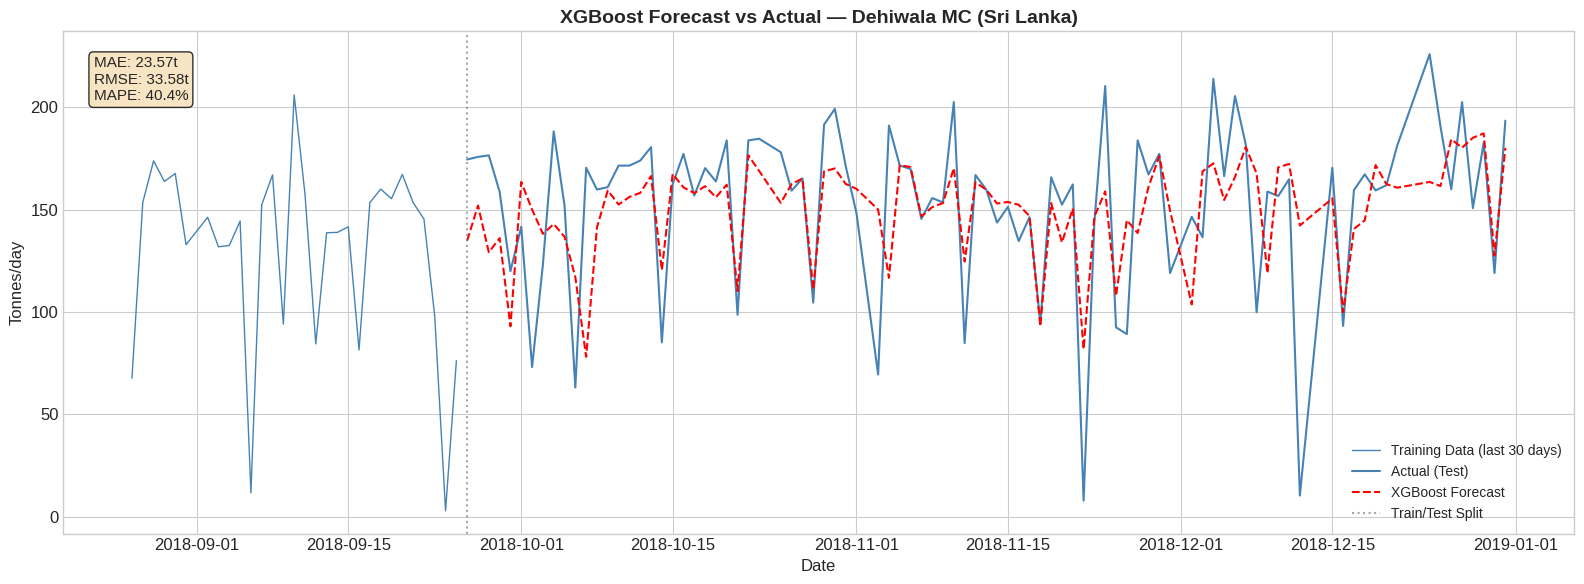

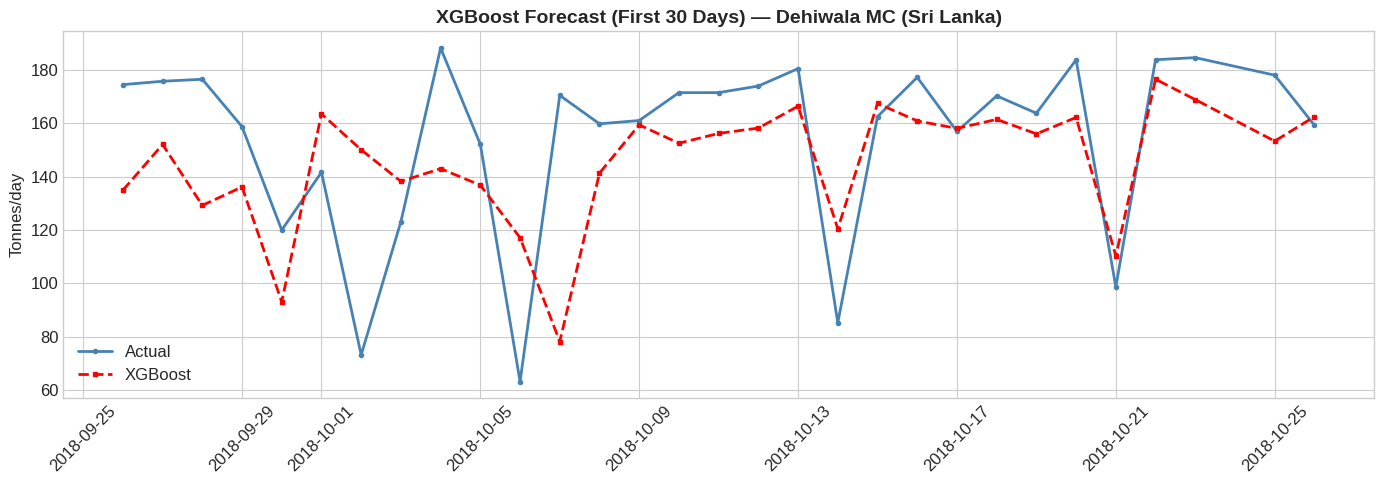

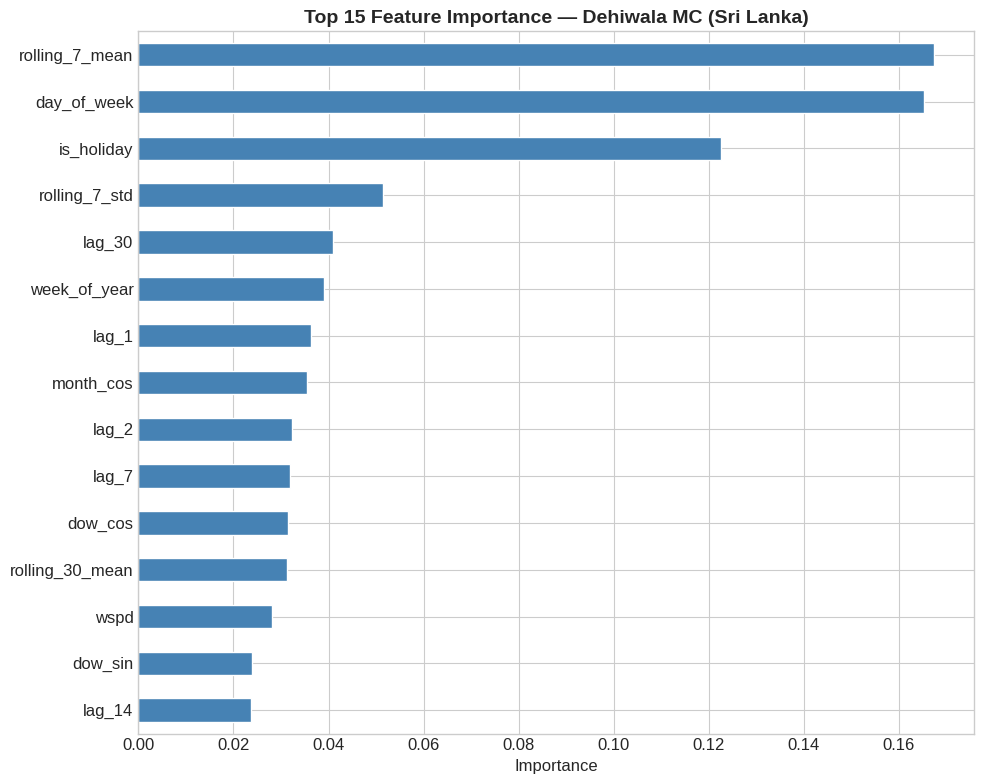


XGBOOST PREDICTION — Homagama PS (Sri Lanka)
Train: 1944 days (2012-02-02 → 2018-09-29)
Test:  90 days (2018-09-30 → 2018-12-31)
Features used: 25
Model trained.

--- RESULTS ---
MAE:  11.04 tonnes
RMSE: 13.56 tonnes
MAPE: 37.21%


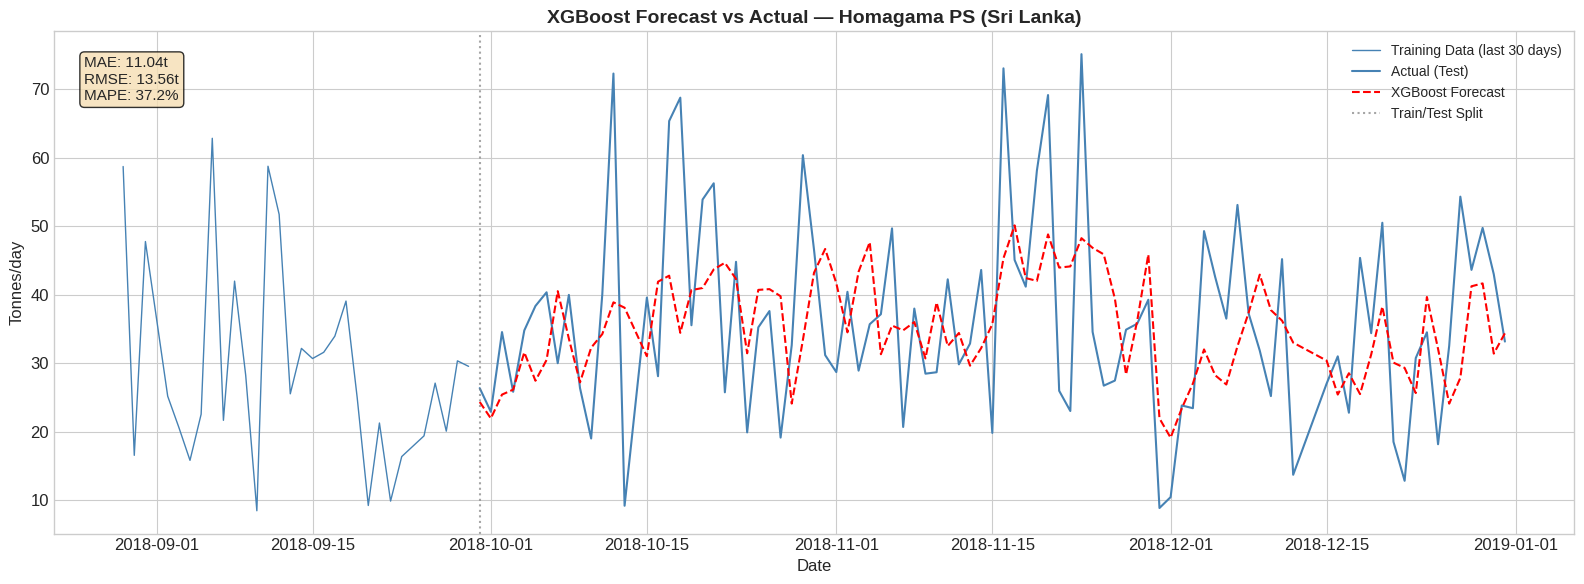

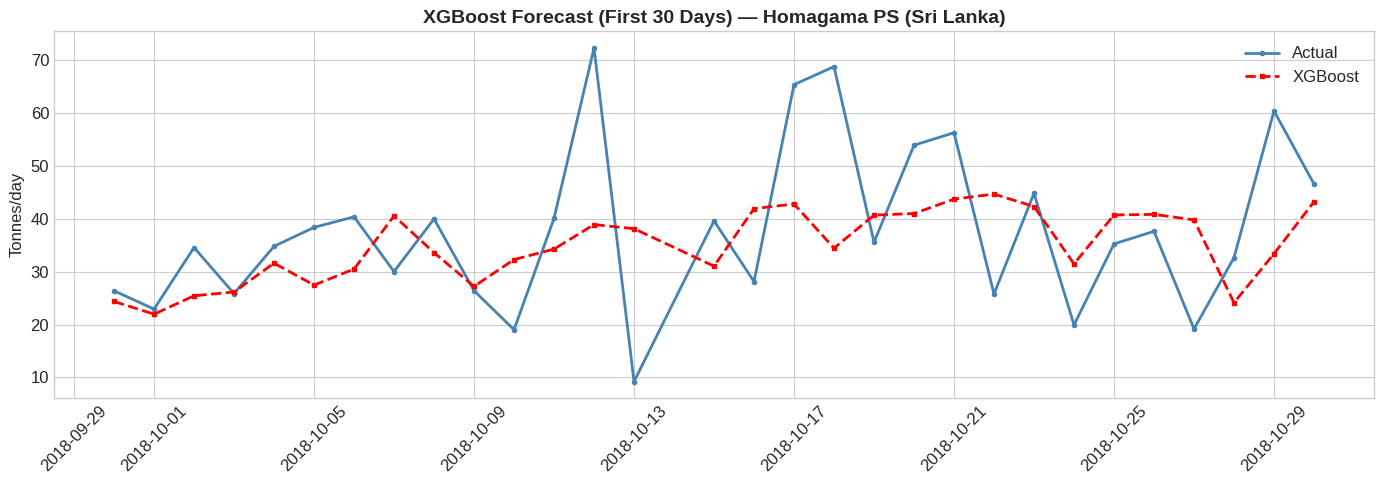

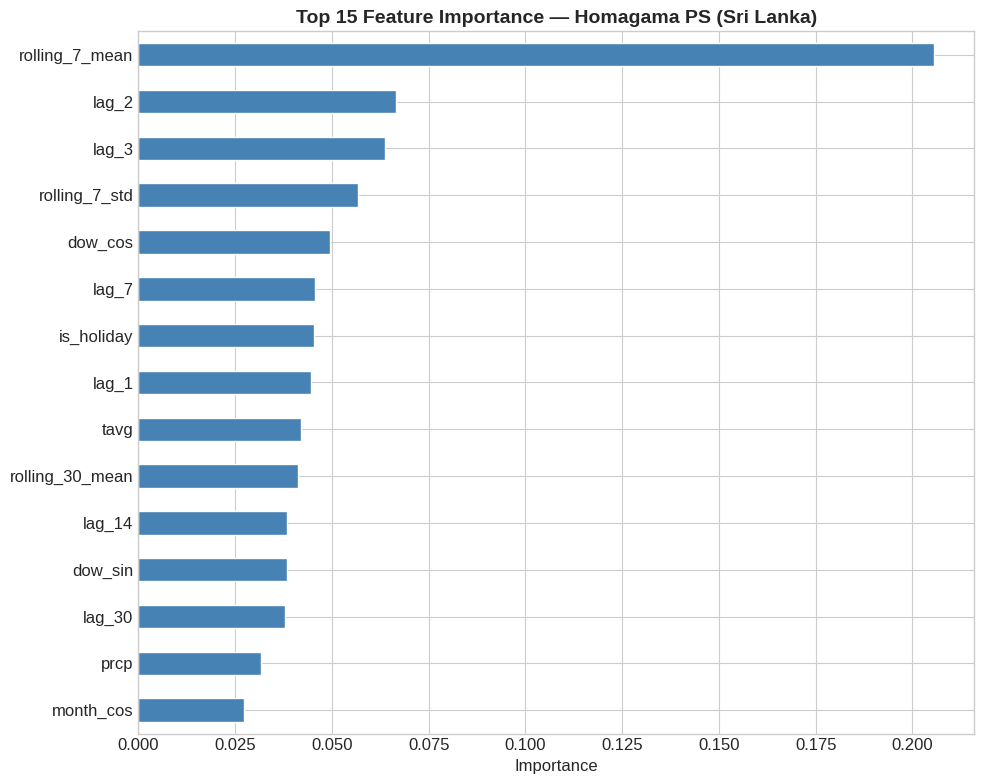


XGBOOST PREDICTION — Moratuwa MC (Sri Lanka)
Train: 1176 days (2015-01-31 → 2018-09-08)
Test:  90 days (2018-09-09 → 2018-12-11)
Features used: 25
Model trained.

--- RESULTS ---
MAE:  20.06 tonnes
RMSE: 25.63 tonnes
MAPE: 31.78%


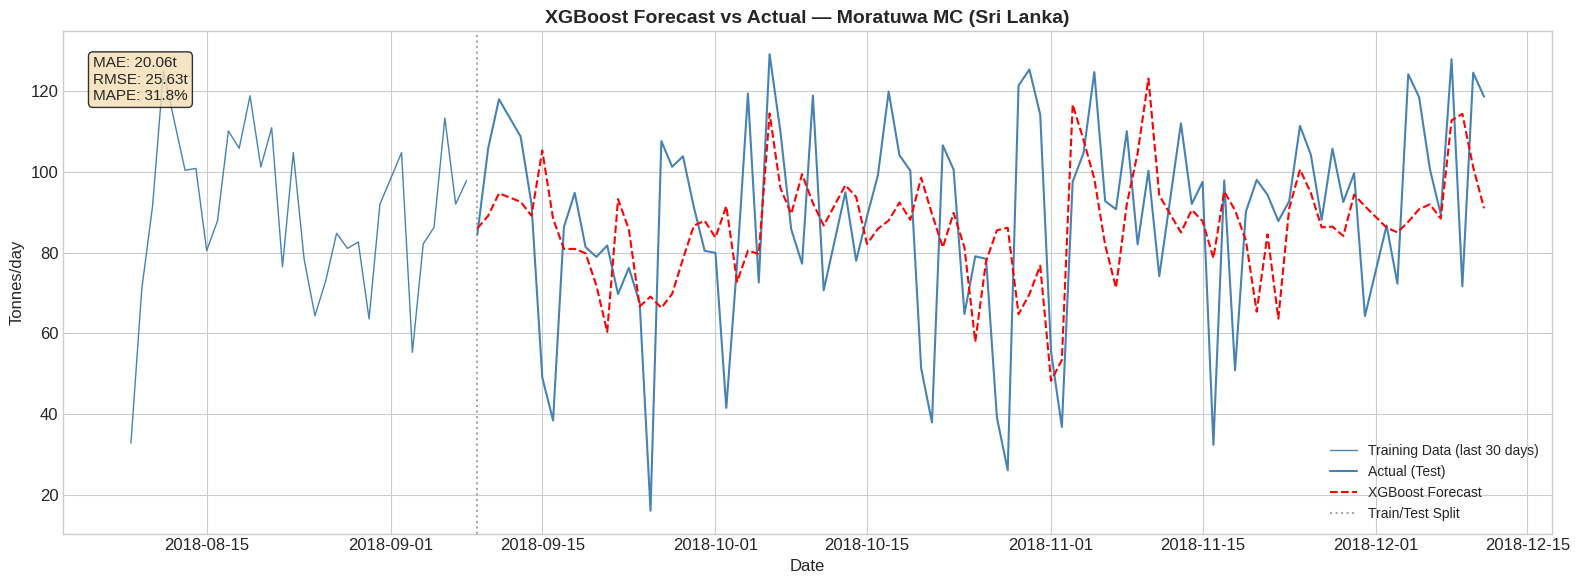

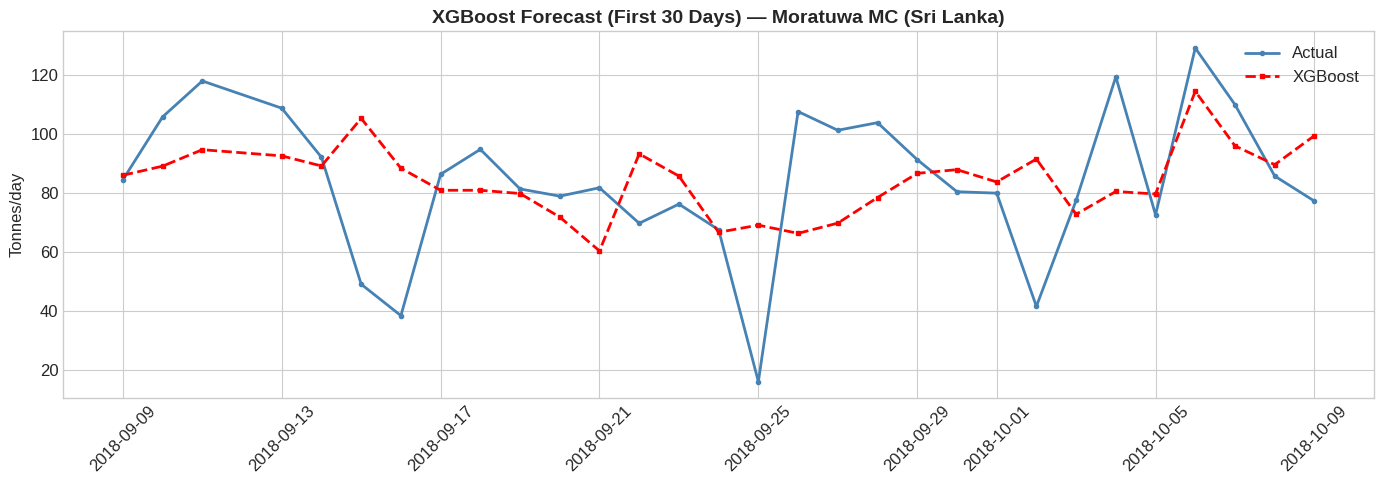

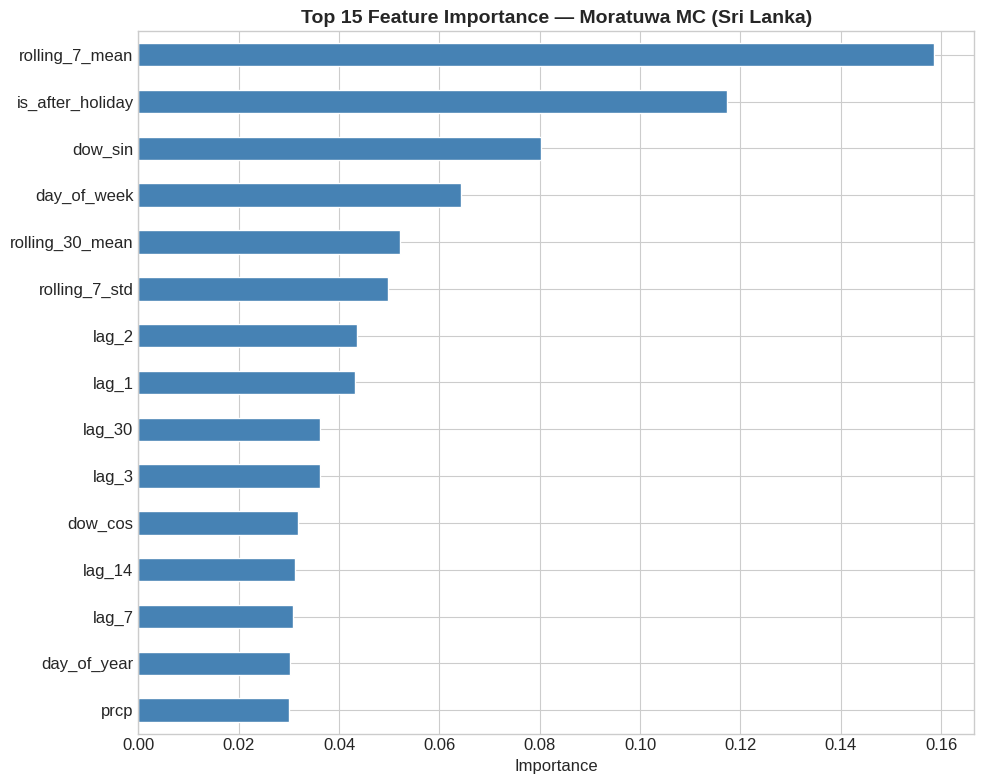


XGBOOST PREDICTION — Austin TX (USA)
Train: 5208 days (2005-02-01 → 2020-09-18)
Test:  90 days (2020-09-19 → 2020-12-31)
Features used: 25
Model trained.

--- RESULTS ---
MAE:  138.22 tonnes
RMSE: 304.51 tonnes
MAPE: 38.91%


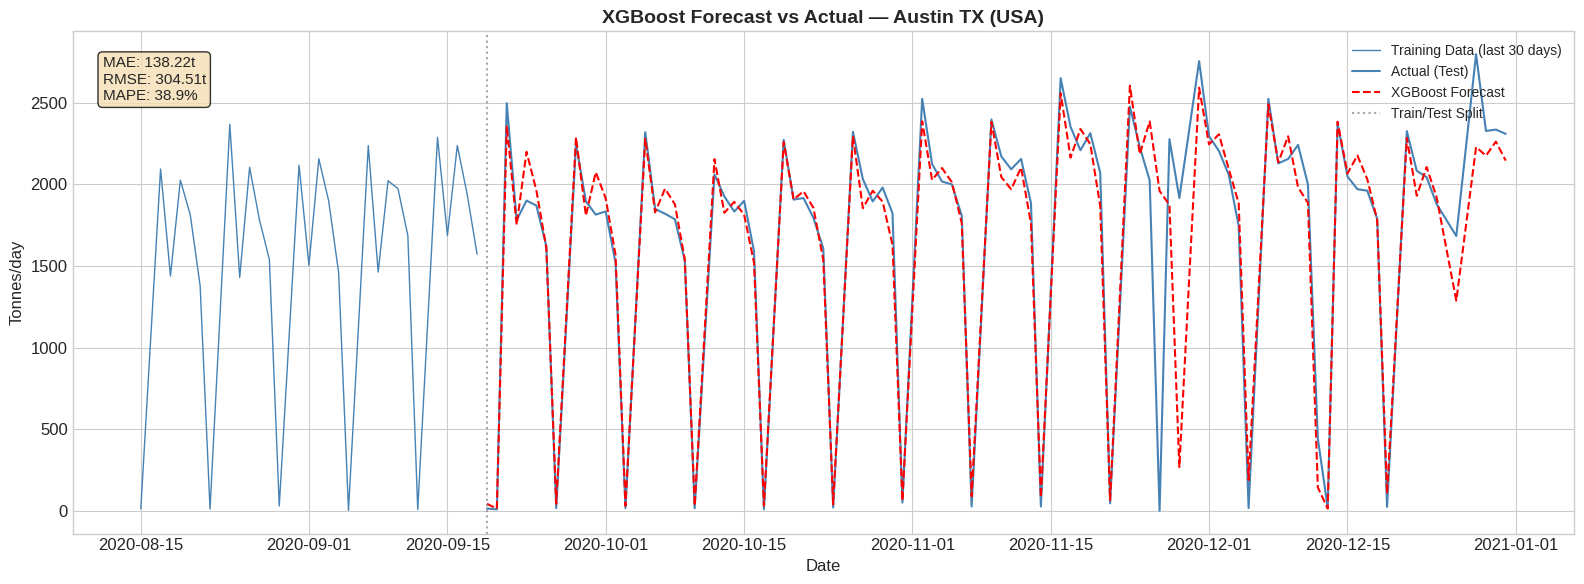

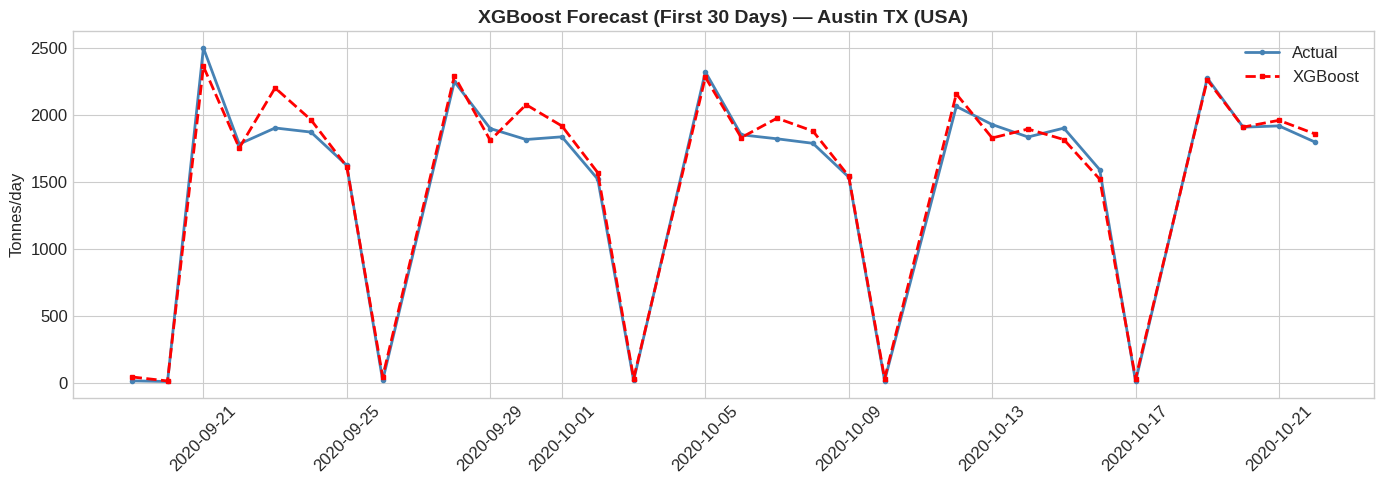

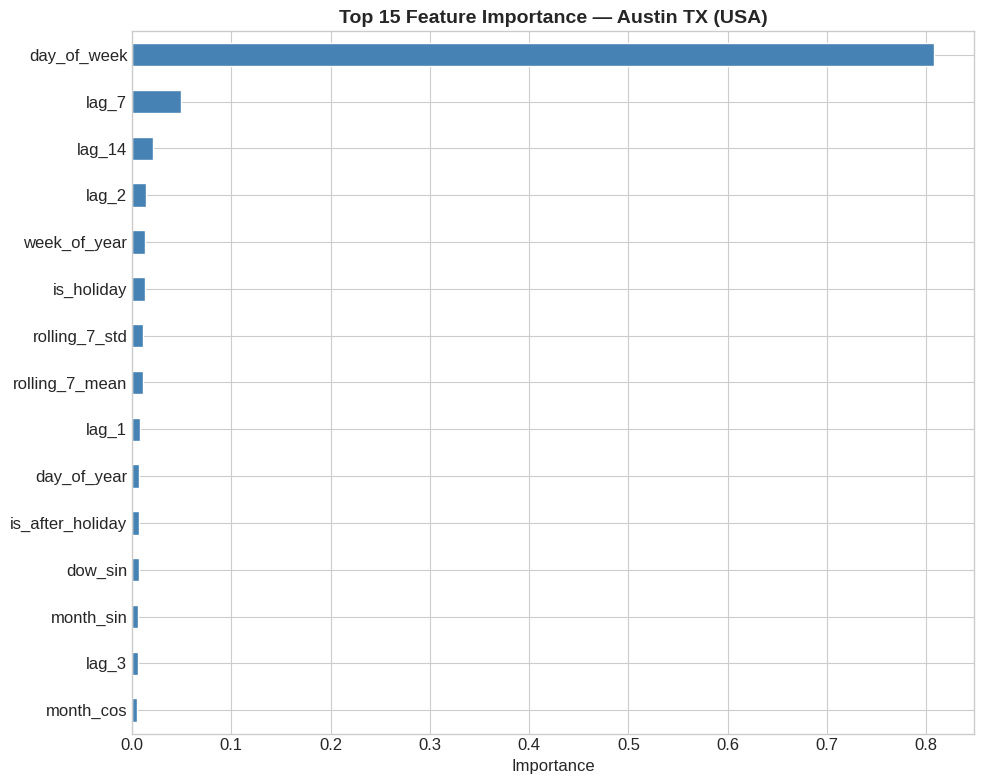


XGBOOST PREDICTION — Ballarat (Australia)
Train: 3570 days (2001-02-01 → 2014-09-17)
Test:  90 days (2014-09-18 → 2014-12-31)
Features used: 25
Model trained.

--- RESULTS ---
MAE:  10.56 tonnes
RMSE: 16.86 tonnes
MAPE: 25.06%


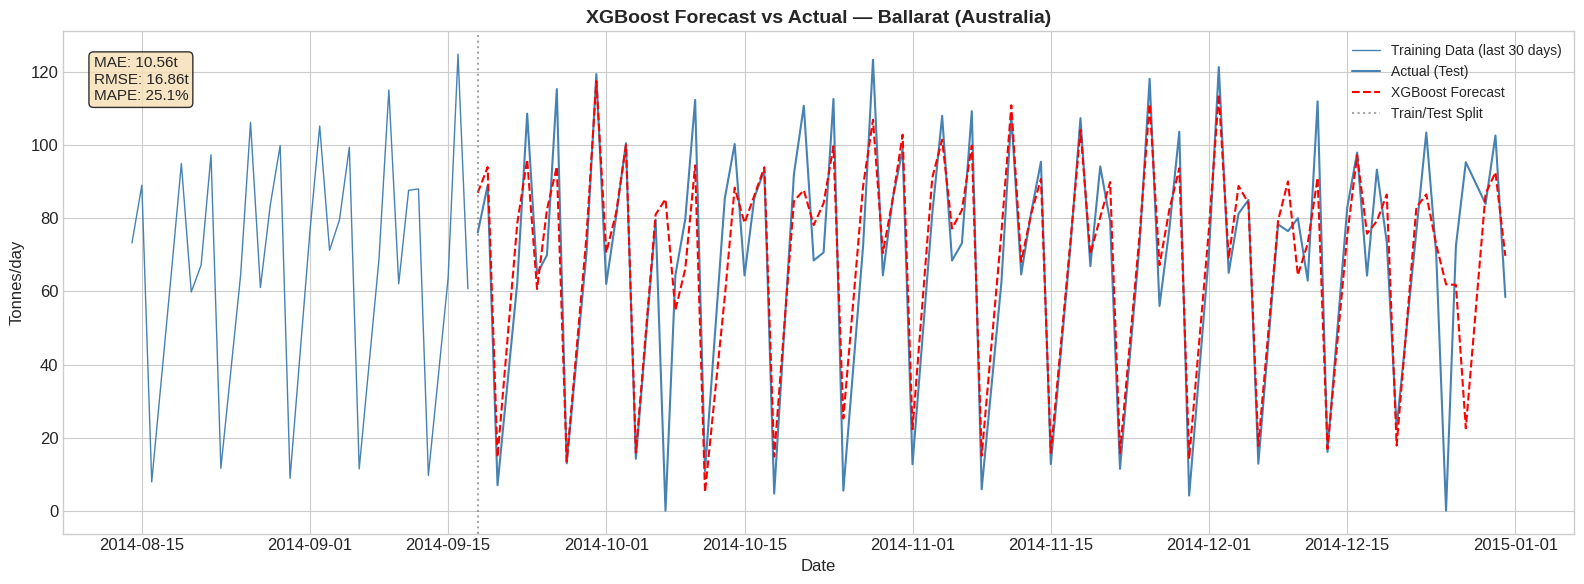

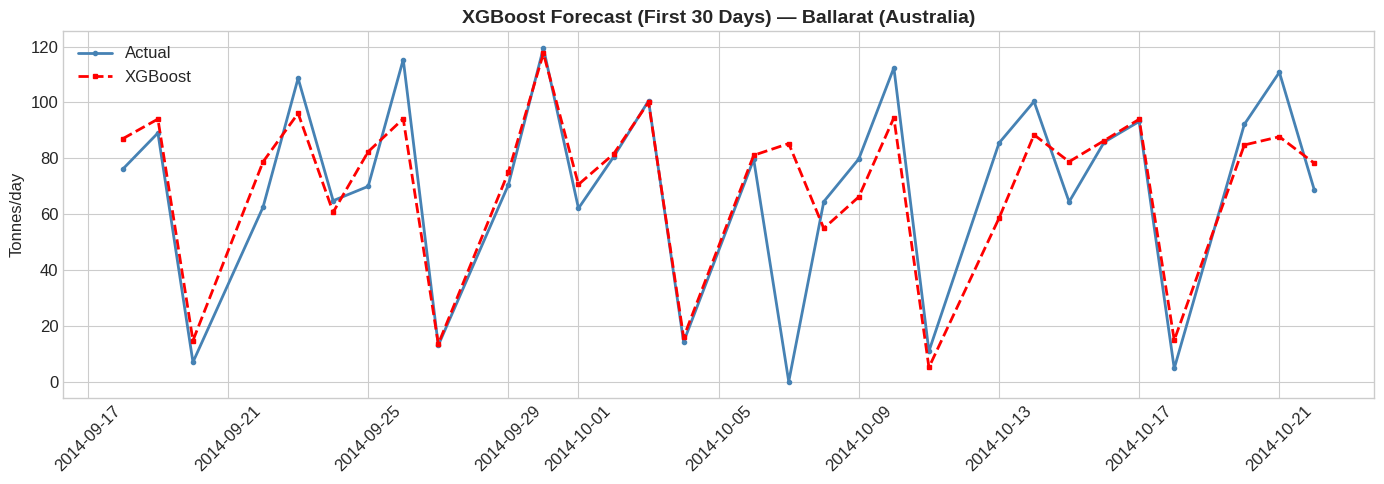

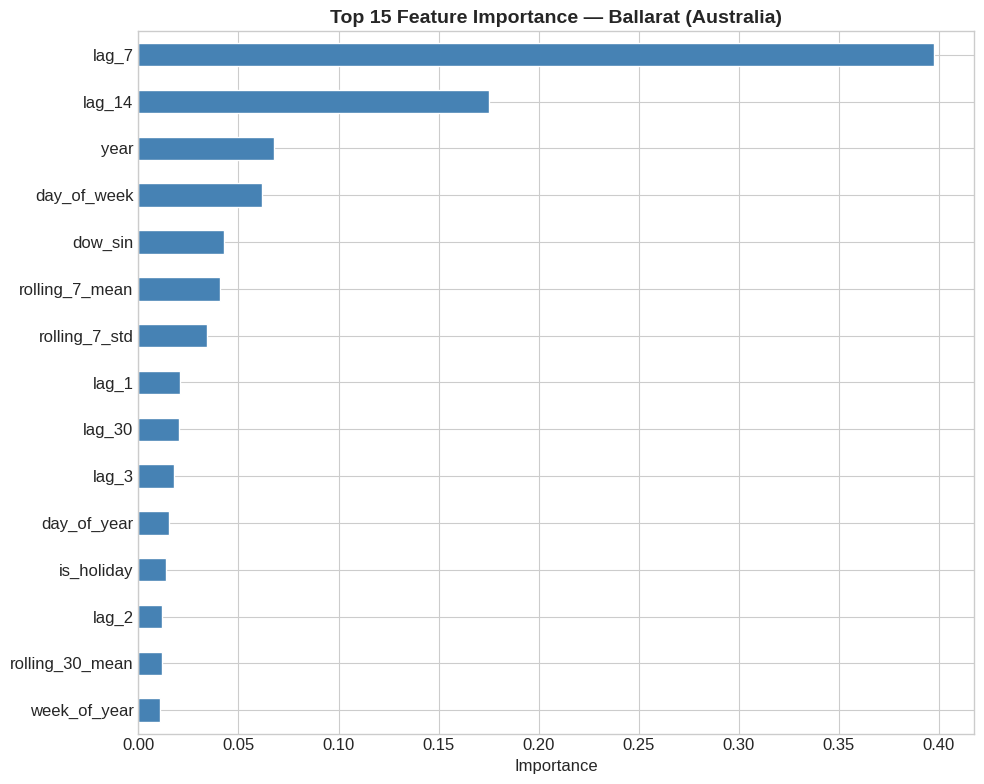

In [9]:
all_results = []

for name, config in DATASETS.items():
    filepath = os.path.join(DATA_DIR, config['file'])

    try:
        df = pd.read_csv(filepath)
        df['date'] = pd.to_datetime(df['date'])

        result = run_xgboost_prediction(
            df = df,
            dataset_name = config['label'],
            dataset_code = config['code'],
            dataset_number = config['number'],
            features = FEATURES,
            test_days = 90
        )
        all_results.append(result)

    except Exception as e:
        print(f"\n{'='*100}")
        print(f"ERROR processing {name}: {e}")
        print(f"{'='*100}")
        import traceback
        traceback.print_exc()

# Prediction Summary

In [10]:
print("\n" + "=" * 100)
print("XGBOOST RESULTS SUMMARY — ALL DATASETS")
print("=" * 100)

results_df = pd.DataFrame(all_results)

print(f"\n{'Dataset':<30s} | {'MAE (t)':>8s} | {'RMSE (t)':>9s} | {'MAPE (%)':>9s}")
print("-" * 75)
for _, row in results_df.iterrows():
    print(f"{row['dataset']:<30s} | {row['mae']:>8.2f} | {row['rmse']:>9.2f} | {row['mape']:>8.2f}%")

# avg metrics
print("-" * 75)
print(f"{'AVERAGE':<30s} | {results_df['mae'].mean():>8.2f} | {results_df['rmse'].mean():>9.2f} | {results_df['mape'].mean():>8.2f}%")

# save results
results_df.to_csv(os.path.join(RES_DIR, 'xgboost_results.csv'), index=False)
print(f"\nResults saved to: {RES_DIR}/xgboost_results.csv")


XGBOOST RESULTS SUMMARY — ALL DATASETS

Dataset                        |  MAE (t) |  RMSE (t) |  MAPE (%)
---------------------------------------------------------------------------
Boralesgamuwa UC (Sri Lanka)   |     5.90 |      8.14 |    39.23%
Dehiwala MC (Sri Lanka)        |    23.57 |     33.58 |    40.41%
Homagama PS (Sri Lanka)        |    11.04 |     13.56 |    37.21%
Moratuwa MC (Sri Lanka)        |    20.06 |     25.63 |    31.78%
Austin TX (USA)                |   138.22 |    304.51 |    38.91%
Ballarat (Australia)           |    10.56 |     16.86 |    25.06%
---------------------------------------------------------------------------
AVERAGE                        |    34.89 |     67.05 |    35.43%

Results saved to: /content/drive/MyDrive/DP/05_prediction_results/xgboost_results.csv


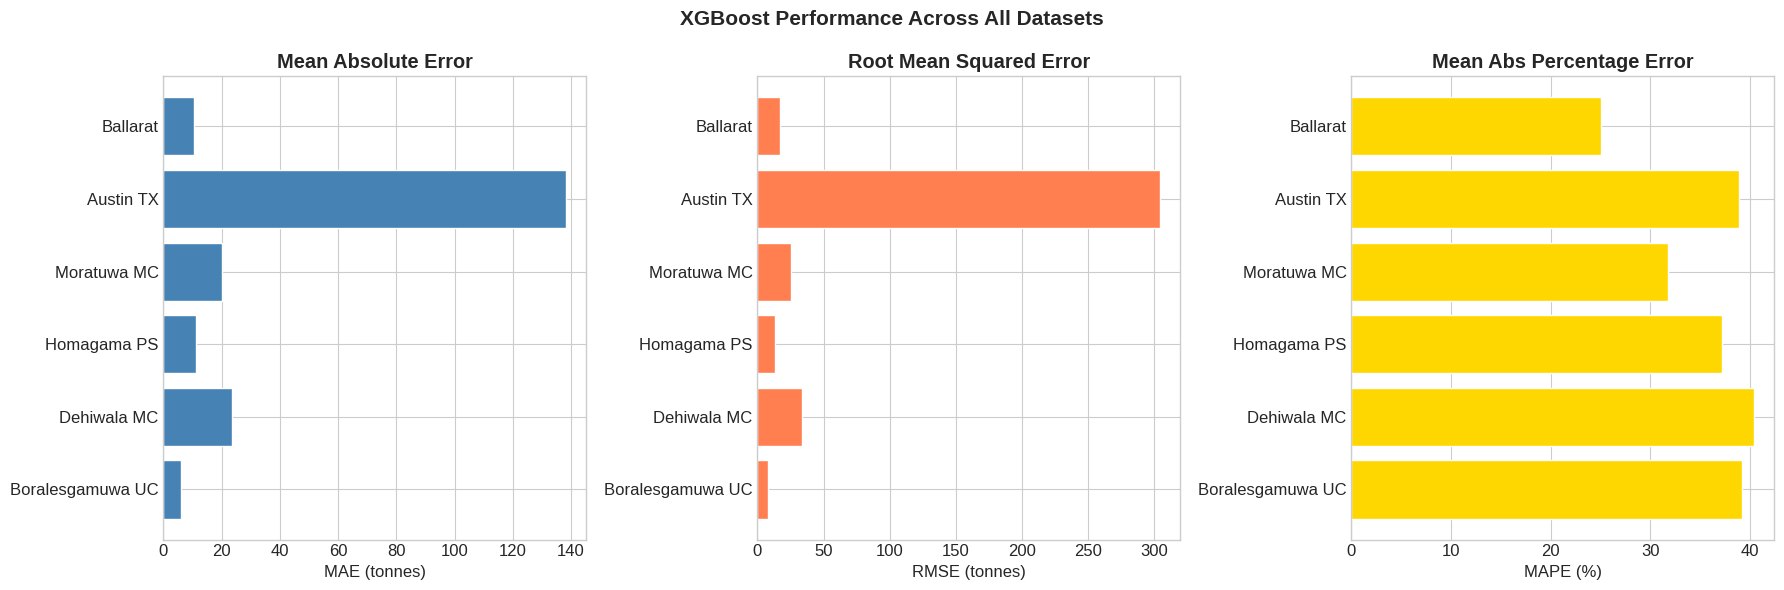

In [11]:
# --- Plot 201: XGBoost Performance ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

short_names = [r['dataset'].split('(')[0].strip() for r in all_results]

# MAE comparison
axes[0].barh(short_names, results_df['mae'], color='steelblue', edgecolor='white')
axes[0].set_xlabel('MAE (tonnes)')
axes[0].set_title('Mean Absolute Error', fontweight='bold')

# RMSE comparison
axes[1].barh(short_names, results_df['rmse'], color='coral', edgecolor='white')
axes[1].set_xlabel('RMSE (tonnes)')
axes[1].set_title('Root Mean Squared Error', fontweight='bold')

# MAPE comparison
axes[2].barh(short_names, results_df['mape'], color='gold', edgecolor='white')
axes[2].set_xlabel('MAPE (%)')
axes[2].set_title('Mean Abs Percentage Error', fontweight='bold')

plt.suptitle('XGBoost Performance Across All Datasets', fontsize=15, fontweight='bold')
plt.tight_layout()

plt.savefig(os.path.join(VIS_DIR, '201_xgb_comparison_all.png'), dpi=150, bbox_inches='tight')
plt.show()